In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(r"E:\Data Science\machine learning\Project\Categorical\bank+marketing\bank-additional\bank-additional\bank-additional-full.csv",sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Data Understanding 

In [3]:
df.shape

(41188, 21)

In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

## Target

In [5]:
df = df.rename(columns={'y': 'subscribed'})

In [6]:
df['subscribed'] = (df['subscribed'] == 'yes').astype(int)

In [7]:
df["subscribed"].value_counts()

subscribed
0    36548
1     4640
Name: count, dtype: int64

In [8]:
df['subscribed'].value_counts(normalize=True) * 100

subscribed
0    88.734583
1    11.265417
Name: proportion, dtype: float64

In [9]:
## The target variable is highly imbalanced: 
## approximately 88.7% of customers did not subscribe to the term deposit, while only 11.3% accepted the offer. 
##This indicates that successful subscriptions are relatively rare events in the dataset.

# Customer Profile Analysis

In [10]:
Customer_Profile = ['age', 'job', 'marital', 'education']

### Age

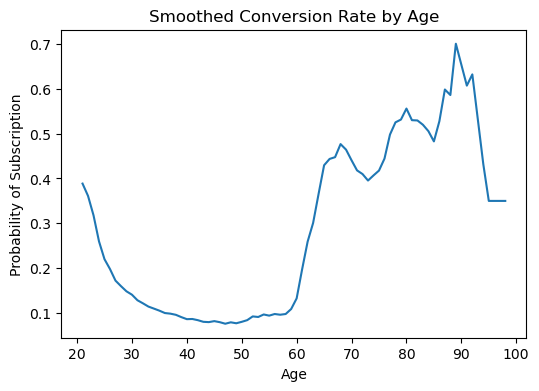

In [11]:
age_rate = df.groupby('age')['subscribed'].apply(lambda x: (x == 1).mean()).reset_index()

age_rate['smoothed'] = age_rate['subscribed'].rolling(window=5).mean()

plt.figure(figsize=(6,4))
plt.plot(age_rate['age'], age_rate['smoothed'])
plt.title('Smoothed Conversion Rate by Age')
plt.xlabel('Age')
plt.ylabel('Probability of Subscription')
plt.show()

##### The raw age-level conversion rate is noisy due to limited observations per age.Therefore, age was grouped into bins to obtain a smoother and more interpretable trend.

In [12]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 100],
    labels=['0-30', '30-45', '45-60', '60+'],
    right=True
)

In [13]:
age_summary = (
    df.groupby('age_group')
      .agg(
          total_customers=('subscribed', 'size'),
          subscribers=('subscribed', 'sum'),
          success_rate=('subscribed', 'mean')
      )
)

age_summary.sort_values(by='success_rate', ascending=False)

,total_customers,subscribers,success_rate
age_group,,,
60+,910,414,0.454945
0-30,7383,1124,0.152242
45-60,10921,1044,0.095596
30-45,21974,2058,0.093656


<Axes: xlabel='age_group'>

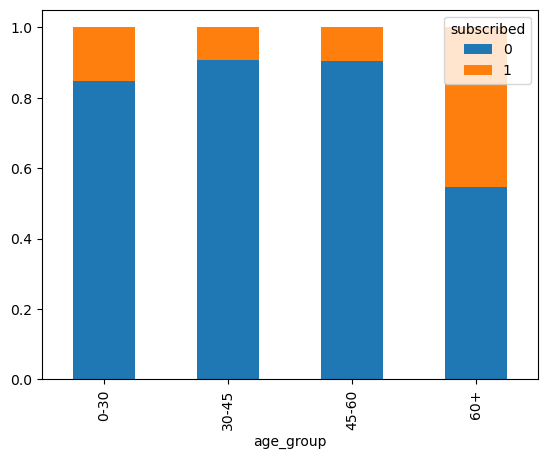

In [129]:
pd.crosstab(df['age_group'], df['subscribed'], normalize='index').plot(kind='bar', stacked=True)

In [16]:
# The analysis shows a clear non-linear relationship between age and subscription probability.
# Customers aged 60+ have a much higher conversion rate (45.5%) compared to all other groups, despite being a small portion of the dataset. 
# In contrast, the 30–60 age group shows the lowest and most stable rates (~9–10%), 
# while the 0–30 group performs slightly better than middle-aged customers.
# Overall, age is a strong segmentation factor, but its effect is non-linear, with retirees being the most responsive to the campaign.

### Job

In [14]:
df["job"].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [15]:
job_summary = (
    df.groupby('job')
      .agg(
          total_customers=('subscribed', 'size'),
          subscribers=('subscribed', 'sum'),
          success_rate=('subscribed', 'mean')
      )
)

job_summary.sort_values(by='success_rate', ascending=False)

,total_customers,subscribers,success_rate
job,,,
student,875,275,0.314286
retired,1720,434,0.252326
unemployed,1014,144,0.142012
admin.,10422,1352,0.129726
management,2924,328,0.112175
unknown,330,37,0.112121
technician,6743,730,0.108260
self-employed,1421,149,0.104856
housemaid,1060,106,0.100000


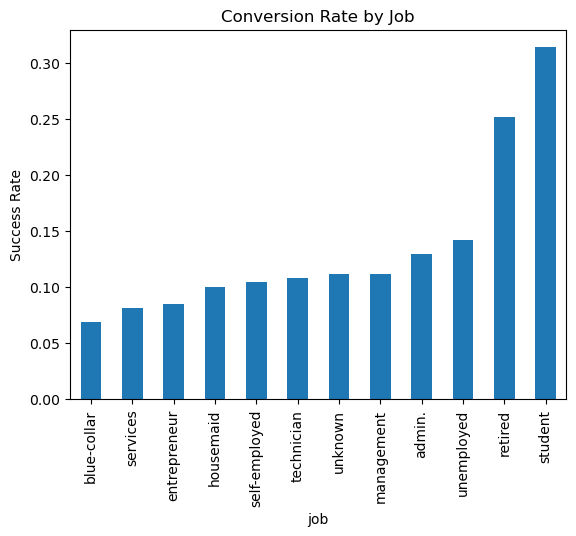

In [21]:
df.groupby('job')['subscribed'].mean().sort_values().plot(kind='bar')
plt.title("Conversion Rate by Job")
plt.ylabel("Success Rate")
plt.show()

In [20]:
# Job categories show clear differences in subscription behavior. Students (31.4%) and retired customers (25.2%) have the highest conversion rates, 
# while blue-collar workers have the lowest (6.9%). Other groups remain in a low and stable range (8–11%).
# Overall, job is a strong but highly segmented predictor of subscription probability, with students and retirees being the most responsive groups.

### Education

In [16]:
df["education"].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [17]:
education_summary = (
    df.groupby('education')
      .agg(
          total_customers=('subscribed', 'size'),
          subscribers=('subscribed', 'sum'),
          success_rate=('subscribed', 'mean')
      )
)

education_summary.sort_values(by='success_rate', ascending=False)

,total_customers,subscribers,success_rate
education,,,
illiterate,18,4,0.222222
unknown,1731,251,0.145003
university.degree,12168,1670,0.137245
professional.course,5243,595,0.113485
high.school,9515,1031,0.108355
basic.4y,4176,428,0.102490
basic.6y,2292,188,0.082024
basic.9y,6045,473,0.078246


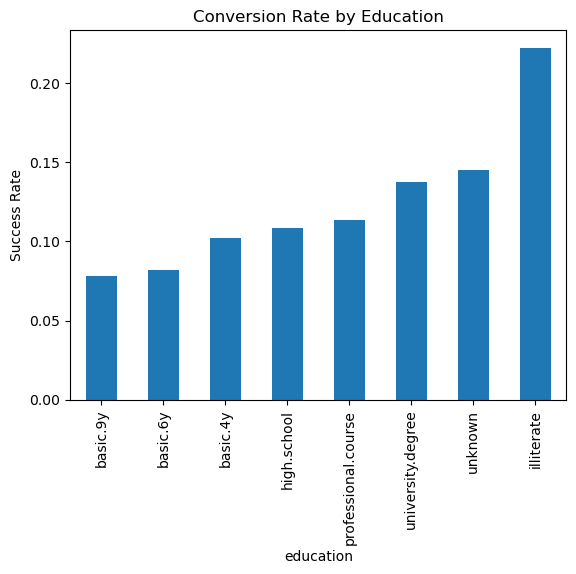

In [18]:
df.groupby('education')['subscribed'].mean().sort_values().plot(kind='bar')
plt.title("Conversion Rate by Education")
plt.ylabel("Success Rate")
plt.show()

##### Education shows a weak-to-moderate relationship with subscription behavior. Higher conversion rates are observed in university graduates (13.7%) and the unknown group (14.5%), while basic education levels consistently show lower engagement (7–10%).
##### The illiterate group appears to have the highest rate (22%), but this result is not reliable due to the very small sample size.
##### Overall, education has limited standalone predictive power and mainly reflects broader socioeconomic differences rather than a strong direct effect.

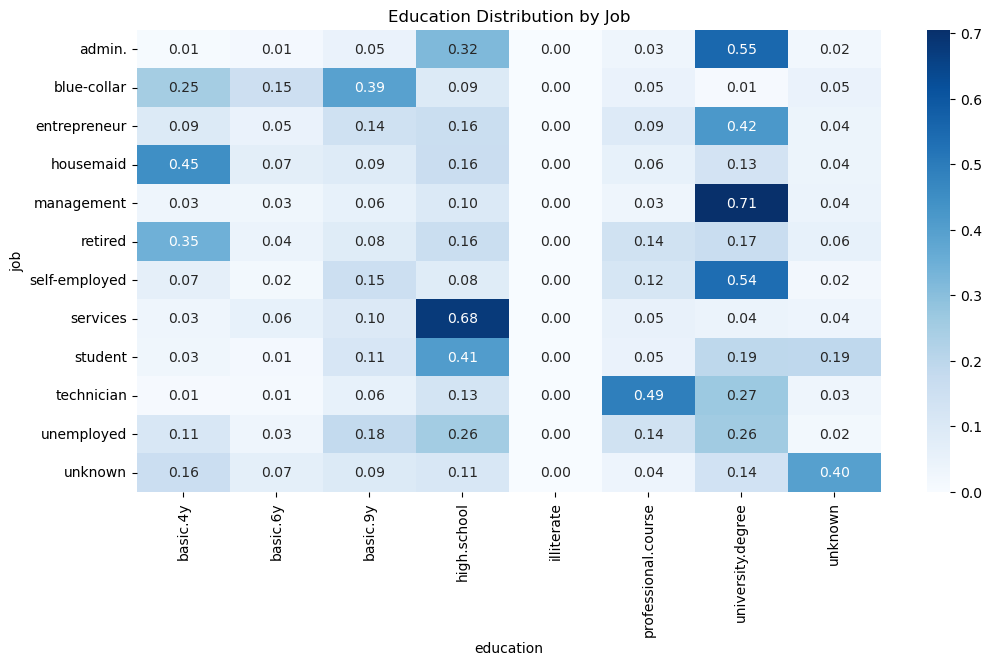

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

table = pd.crosstab(
    df['job'],
    df['education'],
    normalize='index'
)

plt.figure(figsize=(12,6))
sns.heatmap(table, annot=True, cmap='Blues', fmt='.2f')
plt.title('Education Distribution by Job')
plt.show()

##### The analysis shows a strong dependency between job and education, indicating that these variables are closely related rather than independent. Clear socioeconomic patterns emerge: lower education levels are concentrated in blue-collar jobs, while higher education is mainly associated with administrative and management roles. Technical and vocational roles align with professional training, and students are mostly linked with high school education. Overall, job and education reflect a shared underlying socioeconomic structure. While this overlap may reduce their independent predictive power, it is very useful for customer segmentation.

### Marital Status

In [19]:
df["marital"].value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [20]:
marital_summary = (
    df.groupby('marital')
      .agg(
          total_customers=('subscribed', 'size'),
          subscribers=('subscribed', 'sum'),
          success_rate=('subscribed', 'mean')
      )
)

marital_summary.sort_values(by='success_rate', ascending=False)

,total_customers,subscribers,success_rate
marital,,,
unknown,80,12,0.150000
single,11568,1620,0.140041
divorced,4612,476,0.103209
married,24928,2532,0.101573


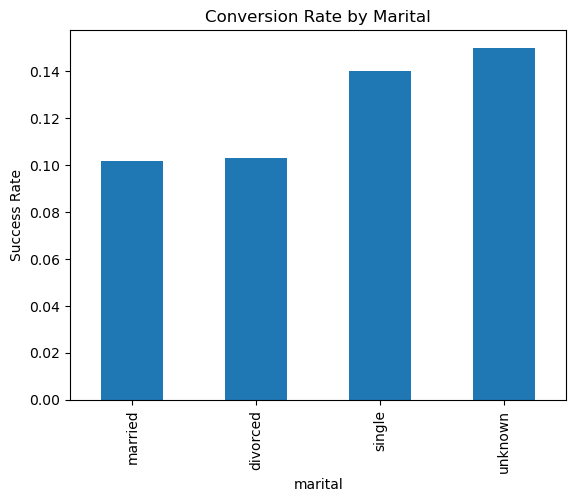

In [21]:
df.groupby('marital')['subscribed'].mean().sort_values().plot(kind='bar')
plt.title("Conversion Rate by Marital")
plt.ylabel("Success Rate")
plt.show()

In [29]:
pd.crosstab(df['marital'], df['age_group'], normalize='index')

age_group,0-30,30-45,45-60,60+
marital,,,,
divorced,0.049653,0.503903,0.407415,0.039029
married,0.095876,0.546654,0.329509,0.027961
single,0.410702,0.517203,0.069416,0.002680
unknown,0.162500,0.500000,0.312500,0.025000


In [128]:
pd.crosstab([df['subscribed'], df['marital']], df['age_group'], normalize='index')

age_group                0-30     30-45     45-60       60+
subscribed marital                                         
0          divorced  0.051015  0.512814  0.413201  0.022969
           married   0.095910  0.555724  0.331443  0.016923
           single    0.391033  0.534278  0.072577  0.002111
           unknown   0.147059  0.500000  0.338235  0.014706
1          divorced  0.037815  0.426471  0.357143  0.178571
           married   0.095577  0.466430  0.312401  0.125592
           single    0.531481  0.412346  0.050000  0.006173
           unknown   0.250000  0.500000  0.166667  0.083333

##### The analysis shows a strong dependency between marital status and age, reflecting clear life-cycle patterns in the data. Single customers are concentrated in younger ages, married individuals dominate middle ages, and divorced customers are more common in older groups.
##### Overall, marital status is not independent of age and mainly captures underlying demographic structure rather than providing separate predictive information.

# Campaign Behavior

In [22]:
campaign = ['contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

#### contact

In [23]:
df["contact"].value_counts(normalize=True) * 100

contact
cellular     63.474798
telephone    36.525202
Name: proportion, dtype: float64

In [24]:
df.groupby("contact")["subscribed"].mean()

contact
cellular     0.147376
telephone    0.052313
Name: subscribed, dtype: float64

In [25]:
# Mobile contacts had a much higher subscription rate (14.7%) than telephone contacts (5.2%), but the reason behind this gap remains unclear.

In [26]:
pd.crosstab(df['contact'], df['age_group'], normalize='index')

age_group,0-30,30-45,45-60,60+
contact,,,,
cellular,0.191095,0.519469,0.258721,0.030715
telephone,0.158668,0.557897,0.276323,0.007112


<Axes: xlabel='age_group'>

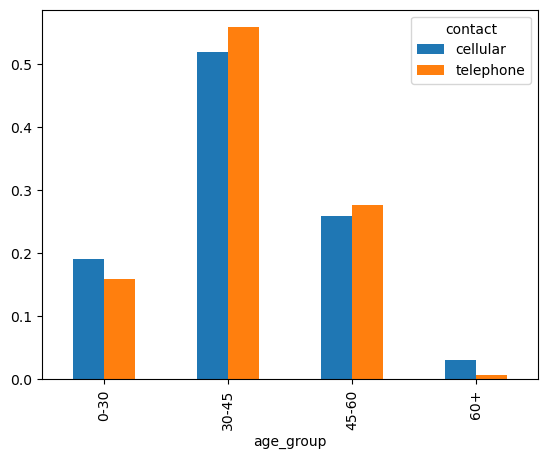

In [27]:
age_contact = pd.crosstab(
   df['contact'],
   df['age_group'],
   normalize='index'
)

age_contact.T.plot(kind='bar')


In [28]:
# Mobile performs better among younger and older customers, while telephone shows relatively higher engagement in the middle-age group. 
#However, the overall gap remains consistent across all age groups, indicating that age alone cannot explain the difference in performance.

#### month

In [29]:
month_summary = (
    df.groupby('month')
      .agg(
          total_customers=('subscribed', 'size'),
          subscribers=('subscribed', 'sum'),
          success_rate=('subscribed', 'mean')
      )
)

month_summary.sort_values(by='success_rate', ascending=False)

,total_customers,subscribers,success_rate
month,,,
mar,546,276,0.505495
dec,182,89,0.489011
sep,570,256,0.449123
oct,718,315,0.438719
apr,2632,539,0.204787
aug,6178,655,0.106021
jun,5318,559,0.105115
nov,4101,416,0.101439
jul,7174,649,0.090466


In [33]:
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

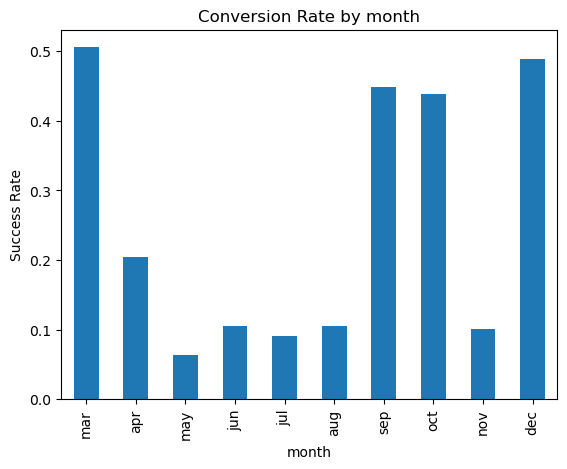

In [34]:
df.groupby('month')['subscribed'].mean().reindex(month_order).plot(kind='bar')
plt.title("Conversion Rate by month")
plt.ylabel("Success Rate")
plt.show()

<Axes: xlabel='month'>

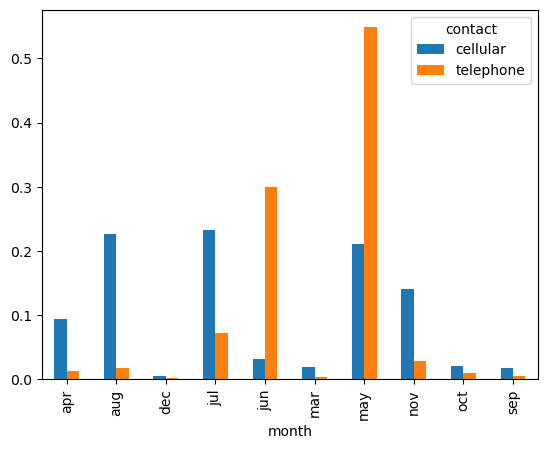

In [37]:
month_sub = pd.crosstab(
   df['contact'],
   df['month'],
    normalize='index'
)

month_sub.T.plot(kind='bar')


In [47]:
pd.crosstab(
   df['contact'],
   df['month'],
   normalize='index'
)

month,apr,aug,dec,jul,jun,mar,may,nov,oct,sep
contact,,,,,,,,,,
cellular,0.093521,0.226017,0.005699,0.233170,0.031365,0.018589,0.211062,0.140606,0.021535,0.018436
telephone,0.012430,0.017881,0.002194,0.071656,0.298990,0.003988,0.548458,0.028250,0.010303,0.005850


#### week

In [39]:
week_summary = (
    df.groupby('day_of_week')
      .agg(
          total_customers=('subscribed', 'size'),
          subscribers=('subscribed', 'sum'),
          success_rate=('subscribed', 'mean')
      )
)

week_summary.sort_values(by='success_rate', ascending=False)

,total_customers,subscribers,success_rate
day_of_week,,,
thu,8623,1045,0.121188
tue,8090,953,0.117800
wed,8134,949,0.116671
fri,7827,846,0.108087
mon,8514,847,0.099483


In [40]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['day_of_week'], df['subscribed'])
chi2, p, dof, expected = chi2_contingency(table)

print(p)

2.9584820052785324e-05


In [42]:
import statsmodels.api as sm
df_model = df.copy()

X = pd.get_dummies(df_model[['day_of_week']], drop_first=True)
X = X.astype(float)

y = df_model['subscribed'].astype(float)
X = sm.add_constant(X)

model1 = sm.Logit(y, X).fit()
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.351707
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                41188
Model:                          Logit   Df Residuals:                    41183
Method:                           MLE   Df Model:                            4
Date:                Sat, 04 Jul 2026   Pseudo R-squ.:               0.0009147
Time:                        12:12:54   Log-Likelihood:                -14486.
converged:                       True   LL-Null:                       -14499.
Covariance Type:            nonrobust   LLR p-value:                 2.480e-05
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.1104      0.036    -57.972      0.000      -2.182      -2.039
day_of_week_mo

##### Subscription rates varied slightly across weekdays, ranging from 9.9% on Monday to 12.1% on Thursday. Although the Chi-square test found a statistically significant association (p < 0.001), the logistic regression model showed that day_of_week has very limited predictive power (Pseudo R² = 0.0009). Overall, the day of contact is not a strong standalone predictor of subscription success, and other factors such as contact channel, campaign strategy, and economic conditions are likely to play a much larger role.

#### campaign

In [43]:
df.groupby('campaign')['subscribed'].mean().head(10)

campaign
1     0.130371
2     0.114570
3     0.107471
4     0.093927
5     0.075047
6     0.076609
7     0.060413
8     0.042500
9     0.060071
10    0.053333
Name: subscribed, dtype: float64

##### The subscription rate consistently declined as the number of contact attempts increased, dropping from 13.0% after the first contact to 5.3% after the tenth contact. This pattern suggests that repeated contact does not improve customer conversion and may instead lead to customer fatigue. From a business perspective, the first few contact attempts appear to be the most effective, while additional calls provide diminishing returns.

#### poutcome

In [122]:
df["poutcome"].value_counts()

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

In [44]:
df.groupby("poutcome")["subscribed"].mean()

poutcome
failure        0.142286
nonexistent    0.088322
success        0.651129
Name: subscribed, dtype: float64

In [51]:
df["pdays"].value_counts().head()

pdays
999    39673
3        439
6        412
4        118
9         64
Name: count, dtype: int64

In [46]:
df['was_contacted_before'] = np.where(df['pdays']==999, 'no', 'yes')
df.groupby('was_contacted_before')['subscribed'].mean()*100

was_contacted_before
no      9.258186
yes    63.828383
Name: subscribed, dtype: float64

##### Previous interactions with customers are among the strongest predictors of subscription success. Customers who had been contacted in an earlier campaign achieved a 63.8% subscription rate, compared with only 9.3% for customers with no previous contact. Similarly, customers whose previous campaign outcome was successful had a 65.1% conversion rate, far exceeding those with a previous failure (14.2%) or no previous campaign (8.8%). These findings suggest that historical customer engagement provides valuable information for predicting future conversions and should play a central role in customer targeting strategies.

# Economic Factor

In [52]:
economic = ['emp.var.rate',	'cons.price.idx','cons.conf.idx','euribor3m','nr.employed', 'subscribed']

In [53]:
df[economic].describe()

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


<Axes: >

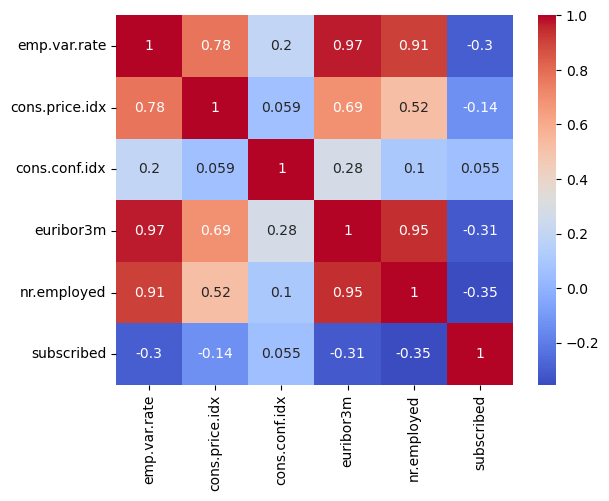

In [54]:
sns.heatmap(df[economic].corr(), cmap = "coolwarm", annot = True)

In [67]:
economic = ['emp.var.rate',	'cons.price.idx','cons.conf.idx','euribor3m','nr.employed', 'subscribed']

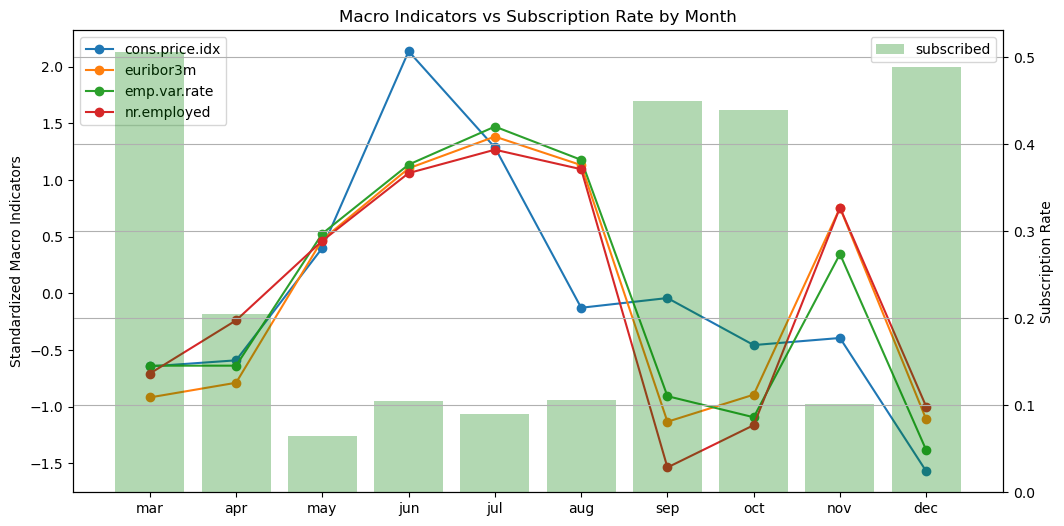

In [55]:
from sklearn.preprocessing import StandardScaler

df_month = df.groupby('month')[[
    'cons.price.idx',
    'euribor3m',
    'emp.var.rate',
    'nr.employed',
    'subscribed'
]].mean().reset_index()


month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

df_month['month'] = pd.Categorical(df_month['month'],
                                   categories=month_order,
                                   ordered=True)

df_month = df_month.sort_values('month')


cols = ['cons.price.idx','euribor3m','emp.var.rate','nr.employed']

scaler = StandardScaler()
df_scaled = df_month.copy()
df_scaled[cols] = scaler.fit_transform(df_month[cols])

fig, ax1 = plt.subplots(figsize=(12,6))

for col in cols:
    ax1.plot(df_scaled['month'], df_scaled[col],
             marker='o', label=col)

ax1.set_ylabel("Standardized Macro Indicators")
ax1.legend(loc='upper left')

ax2 = ax1.twinx()

ax2.bar(df_scaled['month'], df_scaled['subscribed'],
        alpha=0.3, color='green', label='subscribed')

ax2.set_ylabel("Subscription Rate")
ax2.legend(loc='upper right')

plt.title("Macro Indicators vs Subscription Rate by Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### The monthly analysis shows that subscription rates vary alongside changes in macroeconomic indicators, suggesting that customer behavior is influenced by the overall economic environment. While indicators such as interest rates, employment, and inflation exhibit similar trends over time, the subscription rate tends to increase during periods of weaker macroeconomic conditions. This pattern indicates that macroeconomic variables contain valuable predictive information. However, because these indicators are highly correlated, they likely capture the same underlying economic regime. Therefore, feature selection or dimensionality reduction should be considered before including them in predictive models.